In [2]:
!pip install -q -U trl peft transformers datasets accelerate pandas matplotlib

In [3]:
import json, re, random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig
from trl import DPOConfig, DPOTrainer

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cpu":
    print("WARNING: no GPU found. Runtime > Change runtime type > T4 GPU")

Device: cpu


In [4]:
def make_chosen(definition, points, example, summary):
    pts = "\n".join(f"{i+1}. {p}" for i, p in enumerate(points))
    return (f"**Definition:** {definition}\n\n**Key points:**\n{pts}\n\n"
            f"**Example:** {example}\n\n**Summary:** {summary}")

raw = [
 dict(q="What is photosynthesis?",
  chosen=make_chosen("Photosynthesis is the process by which plants, algae and some bacteria convert light energy into chemical energy stored as glucose.",
    ["Light-dependent reactions in the thylakoids capture sunlight and produce ATP and NADPH.",
     "The Calvin cycle in the stroma uses ATP and NADPH to fix CO2 into glucose.",
     "Overall equation: 6CO2 + 6H2O + light -> C6H12O6 + 6O2."],
    "A leaf absorbs sunlight, takes in CO2 through stomata and releases oxygen.",
    "Photosynthesis turns light, water and CO2 into sugar and oxygen."),
  rejected="It's basically how plants do their thing with sunlight. They make food somehow and it's really important for nature."),
 dict(q="Explain Newton's second law of motion.",
  chosen=make_chosen("Newton's second law states that the net force on an object equals its mass times its acceleration (F = ma).",
    ["Force and acceleration are vectors and point in the same direction.",
     "For a fixed force, a larger mass gives a smaller acceleration.",
     "The SI unit of force is the newton: 1 N = 1 kg m/s^2."],
    "Pushing an empty shopping cart with 10 N accelerates it more than pushing a full cart with the same force.",
    "Acceleration grows with net force and shrinks with mass."),
  rejected="Things move when you push them. Heavier things are harder to move, and that is physics. Newton figured it out a long time ago."),
 dict(q="What is supply and demand?",
  chosen=make_chosen("Supply and demand is an economic model describing how the price and quantity of a good are determined in a market.",
    ["Demand: as price rises, buyers purchase less (downward-sloping curve).",
     "Supply: as price rises, sellers offer more (upward-sloping curve).",
     "Equilibrium is where the curves intersect and quantity supplied equals quantity demanded."],
    "If a frost destroys coffee crops, supply falls and the equilibrium price of coffee rises.",
    "Prices move until buyers and sellers want the same quantity."),
  rejected="It is about stuff being expensive or cheap depending on how many people want it. Markets just kind of work like that."),
 dict(q="What is the difference between mitosis and meiosis?",
  chosen=make_chosen("Mitosis produces two genetically identical diploid cells for growth and repair, while meiosis produces four genetically distinct haploid gametes for sexual reproduction.",
    ["Mitosis has one division; meiosis has two (meiosis I and II).",
     "Meiosis includes crossing over and independent assortment, creating variation.",
     "Mitosis keeps the chromosome number (2n -> 2n); meiosis halves it (2n -> n)."],
    "Skin cells healing a cut divide by mitosis; sperm and egg cells form by meiosis.",
    "Mitosis copies cells; meiosis makes varied sex cells."),
  rejected="Both are cell division. One has more steps than the other and they happen in different cells."),
 dict(q="What is inflation?",
  chosen=make_chosen("Inflation is a sustained increase in the general price level of goods and services, which reduces the purchasing power of money.",
    ["It is usually measured by the percentage change in the Consumer Price Index (CPI).",
     "Demand-pull inflation occurs when demand exceeds supply; cost-push occurs when production costs rise.",
     "Central banks often respond by raising interest rates."],
    "If a basket of groceries costs 100 this year and 105 next year, inflation is 5%.",
    "Inflation means each unit of money buys less over time."),
  rejected="Prices go up. It happens in the economy and the government tries to deal with it."),
 dict(q="How does binary search work?",
  chosen=make_chosen("Binary search finds a target value in a sorted array by repeatedly halving the search interval.",
    ["Compare the target with the middle element.",
     "If equal, return the index; if smaller, search the left half; if larger, search the right half.",
     "Each step halves the range, so the time complexity is O(log n)."],
    "To find 7 in [1, 3, 5, 7, 9], check 5, move right, then find 7 in two steps.",
    "Binary search is fast but requires sorted data."),
  rejected="You look for a number in a list by checking the middle part or something. It is faster than normal searching I think."),
 dict(q="What is a derivative in calculus?",
  chosen=make_chosen("The derivative of a function at a point is the instantaneous rate of change of the function, equal to the slope of its tangent line.",
    ["Formally, f'(x) = lim h->0 [f(x+h) - f(x)] / h.",
     "Power rule: d/dx x^n = n x^(n-1).",
     "Derivatives are used for velocity, optimisation and curve sketching."],
    "For f(x) = x^2, f'(x) = 2x, so the slope at x = 3 is 6.",
    "A derivative tells you how fast a quantity is changing."),
  rejected="It is the thing you get when you differentiate. Basically the slope but also limits and other calculus stuff."),
 dict(q="Explain natural selection.",
  chosen=make_chosen("Natural selection is the process by which individuals with heritable traits better suited to their environment survive and reproduce more, so those traits become more common over generations.",
    ["Individuals in a population vary in their traits.",
     "Some variation is heritable and affects survival or reproduction.",
     "Over many generations, advantageous traits increase in frequency."],
    "Dark-coloured moths became more common in polluted areas of England because they were harder for birds to see.",
    "Environment 'selects' traits that improve reproductive success."),
  rejected="The strong survive and the weak die. It is what Darwin said about animals evolving over time."),
 dict(q="What is a p-value in hypothesis testing?",
  chosen=make_chosen("A p-value is the probability of observing data at least as extreme as what was observed, assuming the null hypothesis is true.",
    ["A small p-value (commonly < 0.05) is evidence against the null hypothesis.",
     "It is NOT the probability that the null hypothesis is true.",
     "It does not measure effect size or practical importance."],
    "If a coin gives 9 heads in 10 flips, the p-value is the probability of a result that lopsided or more from a fair coin.",
    "The p-value measures how surprising the data are under the null."),
  rejected="If it is under 0.05 your result is significant and therefore true. Statisticians use it all the time."),
 dict(q="What were the main causes of the French Revolution?",
  chosen=make_chosen("The French Revolution (1789) resulted from a combination of financial crisis, social inequality and new political ideas.",
    ["Financial: war debts and an inefficient tax system left the state near bankruptcy.",
     "Social: the Third Estate carried most taxes while the clergy and nobility had privileges.",
     "Intellectual: Enlightenment ideas of liberty and popular sovereignty challenged absolute monarchy."],
    "Poor harvests in 1788 raised bread prices and fuelled unrest in Paris.",
    "Debt, inequality and Enlightenment ideas combined to topple the old regime."),
  rejected="The king was bad and people were hungry so they got angry and there was a revolution in France."),
 dict(q="What is osmosis?",
  chosen=make_chosen("Osmosis is the net movement of water across a selectively permeable membrane from lower solute concentration to higher solute concentration.",
    ["Water moves to equalise solute concentration on both sides.",
     "It needs no energy input (passive transport).",
     "Cells swell in hypotonic solutions and shrink in hypertonic solutions."],
    "Placing a raisin in water makes it swell as water enters.",
    "Osmosis is water diffusion driven by solute concentration."),
  rejected="Water moves through membranes. It is like diffusion but different, and cells need it."),
 dict(q="What is overfitting in machine learning?",
  chosen=make_chosen("Overfitting occurs when a model learns the noise and details of the training data so well that it performs poorly on new, unseen data.",
    ["Symptom: very low training error but high validation/test error.",
     "Causes: overly complex model, too little data, too many training epochs.",
     "Remedies: regularisation, more data, cross-validation, early stopping."],
    "A degree-15 polynomial passes through every training point but oscillates wildly between them.",
    "An overfit model memorises instead of generalising."),
  rejected="Overfitting is when the model is too good and then it does not work. You should use regularization and stuff."),
 dict(q="What is opportunity cost?",
  chosen=make_chosen("Opportunity cost is the value of the next-best alternative given up when a choice is made.",
    ["It includes implicit costs, not just money spent.",
     "It exists because resources such as time and money are scarce.",
     "It helps compare options rationally."],
    "Spending Saturday studying instead of working a paid shift costs you the wages you would have earned.",
    "Every choice has a cost: the best option you did not pick."),
  rejected="It is what you lose when you pick something. Like a cost, but not really a cost, it is more like economics."),
 dict(q="What is chemical equilibrium?",
  chosen=make_chosen("Chemical equilibrium is the state of a reversible reaction in which the forward and reverse reaction rates are equal, so concentrations stay constant.",
    ["It is dynamic: reactions continue in both directions.",
     "The equilibrium constant K = [products]/[reactants] (with stoichiometric powers).",
     "Le Chatelier's principle predicts how the system shifts when conditions change."],
    "In N2 + 3H2 <=> 2NH3, raising pressure shifts the equilibrium towards ammonia.",
    "At equilibrium nothing appears to change, but both reactions still run."),
  rejected="It is when a reaction stops. Everything is balanced and the chemicals stay the same forever."),
 dict(q="What is Big O notation?",
  chosen=make_chosen("Big O notation describes an upper bound on how an algorithm's running time or memory grows as input size n increases.",
    ["It ignores constants and lower-order terms: 3n^2 + 5n is O(n^2).",
     "Common classes: O(1), O(log n), O(n), O(n log n), O(n^2).",
     "It is typically used for worst-case analysis."],
    "Looking up an element by index in an array is O(1); scanning a list for a value is O(n).",
    "Big O shows how an algorithm scales, not its exact speed."),
  rejected="Asymptotic upper-bound characterisation of computational complexity functions under limiting behaviour of the argument toward infinity per the formal Landau definition."),
 dict(q="How does DNA replication work?",
  chosen=make_chosen("DNA replication is the semi-conservative process by which a cell copies its DNA before division.",
    ["Helicase unwinds the double helix at the origin of replication.",
     "DNA polymerase adds nucleotides to the 3' end of a primer, building new strands complementary to the templates.",
     "The leading strand is made continuously; the lagging strand in Okazaki fragments joined by ligase."],
    "Each daughter DNA molecule has one original and one new strand.",
    "Replication unwinds, copies and joins DNA so each cell gets a full genome."),
  rejected="The DNA copies itself with enzymes. It is complicated and happens in the cell before it divides."),
]
print(len(raw), "preference pairs created")

16 preference pairs created


In [5]:
def to_dpo_row(r):
    return {
        "prompt":   [{"role": "user", "content": r["q"]}],
        "chosen":   [{"role": "assistant", "content": r["chosen"]}],
        "rejected": [{"role": "assistant", "content": r["rejected"]}],
    }

rows = [to_dpo_row(r) for r in raw]
train_ds = Dataset.from_list(rows)

with open("academic_preferences.jsonl", "w") as f:
    for r in rows:
        f.write(json.dumps(r) + "\n")

print(train_ds)
print(json.dumps(rows[0], indent=2)[:700])

Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 16
})
{
  "prompt": [
    {
      "role": "user",
      "content": "What is photosynthesis?"
    }
  ],
  "chosen": [
    {
      "role": "assistant",
      "content": "**Definition:** Photosynthesis is the process by which plants, algae and some bacteria convert light energy into chemical energy stored as glucose.\n\n**Key points:**\n1. Light-dependent reactions in the thylakoids capture sunlight and produce ATP and NADPH.\n2. The Calvin cycle in the stroma uses ATP and NADPH to fix CO2 into glucose.\n3. Overall equation: 6CO2 + 6H2O + light -> C6H12O6 + 6O2.\n\n**Example:** A leaf absorbs sunlight, takes in CO2 through stomata and releases oxygen.\n\n**Summary:** Photosynthesis turns light, wate


In [6]:
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float32).to(device)
print("Parameters:", round(sum(p.numel() for p in model.parameters())/1e6), "M")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Parameters: 494 M


In [7]:
test_questions = [
    "What is Ohm's law?",
    "What is Gross Domestic Product (GDP)?",
    "Explain recursion in programming.",
    "What is plate tectonics?",
    "What is standard deviation?",
    "What is classical conditioning?",
]

@torch.no_grad()
def generate_answers(m, questions, max_new_tokens=300):
    m.eval()
    outs = []
    for q in questions:
        msgs = [{"role": "user", "content": q}]
        text = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(text, return_tensors="pt").to(m.device)
        ids = m.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False,
                         repetition_penalty=1.05, pad_token_id=tokenizer.pad_token_id)
        outs.append(tokenizer.decode(ids[0, inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip())
    return outs

In [9]:
for name in ["model", "tokenizer", "train_ds", "test_questions", "generate_answers", "SEED"]:
    assert name in globals(), f"'{name}' missing -> run the earlier cells (2, 3, 4, 5, 6) first"

print("Device:", device)
print("CUDA available:", torch.cuda.is_available())
print("Model on:", next(model.parameters()).device)
print("Train pairs:", len(train_ds))

Device: cpu
CUDA available: False
Model on: cpu
Train pairs: 16


In [12]:
peft_config = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    task_type="CAUSAL_LM",
)

use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()

training_args = DPOConfig(
    output_dir="dpo_academic_model",
    beta=0.1,
    learning_rate=5e-5,
    num_train_epochs=5,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    max_length=512,
    logging_steps=1,
    save_strategy="no",
    bf16=use_bf16,
    fp16=False,
    report_to="none",
    seed=SEED,
)

In [14]:
import gc
del model; gc.collect()
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float32)
torch.set_num_threads(max(1, torch.get_num_threads()))
print("Fresh model loaded")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Fresh model loaded


In [15]:
peft_config = LoraConfig(
    r=8, lora_alpha=16, lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],        # fewer modules = faster
    task_type="CAUSAL_LM",
)

training_args = DPOConfig(
    output_dir="dpo_academic_model",
    beta=0.1,
    learning_rate=1e-4,
    max_steps=16,                               # replaces epochs: a short, bounded run
    per_device_train_batch_size=1,
    gradient_accumulation_steps=2,
    max_length=256,
    logging_steps=1,
    save_strategy="no",
    bf16=False, fp16=False,
    use_cpu=True,
    dataloader_num_workers=0,
    report_to="none",
    seed=SEED,
)

In [17]:
trainer = DPOTrainer(model=model, ref_model=None, args=training_args,
                     train_dataset=train_ds, processing_class=tokenizer,
                     peft_config=peft_config)
trainer.train()

Tokenizing train dataset:   0%|          | 0/16 [00:00<?, ? examples/s]

Dropping fully truncated examples from train dataset:   0%|          | 0/16 [00:00<?, ? examples/s]

Step,Training Loss
1,0.693147
2,0.648262
3,0.592999
4,0.513490
5,0.516658
6,0.460191
7,0.413318
8,0.395974
9,0.326489
10,0.339527


TrainOutput(global_step=16, training_loss=0.3991976184770465, metrics={'train_runtime': 252.6017, 'train_samples_per_second': 0.127, 'train_steps_per_second': 0.063, 'total_flos': 22400990244864.0, 'train_loss': 0.3991976184770465, 'epoch': 2.0})

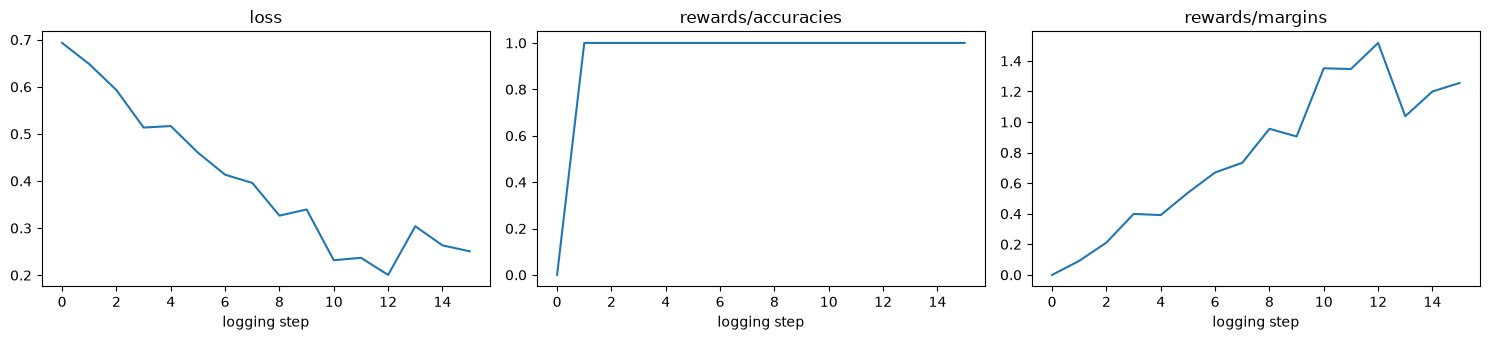

Adapter saved to dpo_academic_adapter/


In [18]:
log = pd.DataFrame(trainer.state.log_history)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, col in zip(axes, ["loss", "rewards/accuracies", "rewards/margins"]):
    if col in log:
        ax.plot(log[col].dropna().values)
    ax.set_title(col); ax.set_xlabel("logging step")
plt.tight_layout(); plt.show()

trainer.model.save_pretrained("dpo_academic_adapter")
tokenizer.save_pretrained("dpo_academic_adapter")
print("Adapter saved to dpo_academic_adapter/")

In [25]:
assert "trainer" in globals(), "trainer missing -> run the DPOTrainer cell and let trainer.train() finish"
assert trainer.state.global_step > 0, "Training did not run any steps -> re-run trainer.train() and wait for it to finish"

print("Training steps completed:", trainer.state.global_step)
print("Device:", next(trainer.model.parameters()).device)

Training steps completed: 16
Device: cpu


In [26]:
# Save the LoRA adapter first (needed for Cell 10 of the notebook)
trainer.model.save_pretrained("dpo_academic_adapter")
tokenizer.save_pretrained("dpo_academic_adapter")

# Merging removes the LoRA overhead, so generation is faster
dpo_model = trainer.model.merge_and_unload()
dpo_model.eval()
print("DPO model ready")

DPO model ready


In [32]:
for name in ["test_questions", "generate_answers", "after_answers", "MODEL_NAME", "tokenizer", "device"]:
    print(f"{name:18s}", "OK" if name in globals() else "MISSING")

test_questions     OK
generate_answers   OK
after_answers      MISSING
MODEL_NAME         OK
tokenizer          OK
device             OK


In [ ]:
import gc

base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float32).to(device)
base_model.eval()

before_answers = generate_answers(base_model, test_questions)

del base_model; gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [ ]:
comparison = pd.DataFrame({"question": test_questions,
                           "before_DPO": before_answers,
                           "after_DPO": after_answers})
comparison.to_csv("before_after_comparison.csv", index=False)

for _, r in comparison.iterrows():
    print("="*90)
    print("QUESTION:", r.question)
    print("\n--- BEFORE DPO ---\n" + r.before_DPO)
    print("\n--- AFTER DPO ---\n" + r.after_DPO)

In [ ]:
def style_metrics(text):
    lines = [l for l in text.split("\n") if l.strip()]
    return {
        "words": len(text.split()),
        "numbered_points": sum(bool(re.match(r"\s*\d+[.)]", l)) for l in lines),
        "bold_labels": len(re.findall(r"\*\*[^*]+\*\*", text)),
        "has_definition": int("definition" in text.lower()),
        "has_example": int("example" in text.lower()),
        "has_summary": int("summary" in text.lower()),
    }

mb = pd.DataFrame([style_metrics(a) for a in before_answers]).mean().rename("before_DPO")
ma = pd.DataFrame([style_metrics(a) for a in after_answers]).mean().rename("after_DPO")
metrics = pd.concat([mb, ma], axis=1).round(2)
metrics["change"] = (metrics["after_DPO"] - metrics["before_DPO"]).round(2)
display(metrics)

metrics[["before_DPO", "after_DPO"]].plot(kind="bar", figsize=(9, 4), title="Average style metrics (6 unseen questions)")
plt.xticks(rotation=30); plt.tight_layout(); plt.show()